# Categorizing Complaint Types Using Topic Modeling

### 0.0) import packages & load data

In [ ]:
import pandas as pd
import gensim
from gensim import corpora
import spacy


data = pd.read_csv("preCategories.csv")

## 1) text processing
NOTE- the model takes ~20 min to run

### 1.1) topic modeling

In [ ]:
df = data


nlp = spacy.load("en_core_web_sm")

def preprocess_311(text):
    """Lemmatizes and filters for nouns/adjectives only."""
    doc = nlp(str(text).lower())

    # keeping nouns and adjectives bc they provide the best thematic signals for LDA
    return [token.lemma_ for token in doc if token.pos_ in ['NOUN', 'ADJ'] and not token.is_stop]

df['tokens'] = df['problem'].apply(preprocess_311)

# create dictionary and corpus (gensim workflow)
id2word = corpora.Dictionary(df['tokens'])

# filter out outlier words (any that appear in less than 5 documents or more than 50%)
id2word.filter_extremes(no_below=5, no_above=0.5) 
corpus = [id2word.doc2bow(text) for text in df['tokens']]

# train the model
# we ended up with 10 manual categories so gonna start with num_topics=10.
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=10, 
    random_state=42,
    passes=10,
    alpha='auto'
)

# review the 'Discovered' categories
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}\n")

In [ ]:
# Create a dictionary for the new labels
topic_labels = {
    0: "parks_safety",           # Parks & public safety, primarily regulatory (inspections)
    1: "nuisance_qol",           # noise complaints, air quality issues
    2: "eyesores",               # Unsanitary conditions, pest control (mostly private property issues)
    3: "obstacles",              # issues with street or sidewalk access
    4: "trash",                  # trash collection
    5: "street_maintenance",     # for actual road quality issues (repair complaints)
    6: "illegal_activity",       # reports of illegal parking and dumping
    7: "hpd",                    # dept of housing preservation and development, homelessness
    8: "subterranean",           # infrastructure issues around sewers, rodents, street sweeping
    9: "interior"                # relating to paint, plaster, litter
}

def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)

    # get the topic ID with the highest probability
    dominant_topic_id = sorted(topic_probs, key=lambda x: x[1], reverse=True)[0][0]
    return topic_labels[dominant_topic_id]

# apply to corpus
df['lda_category'] = [get_dominant_topic(c) for c in corpus]


## 2) replicating the rest of the process using this version

Not going to include the other 311 categories, because they weren't integral to our analysis and I'm mostly trying to see how this impacts the complaint category relationships to the census data.

### 2.1) create count dataframe by zipyear

In [26]:
# make a contingency table for the categorized problem groups
ProblemFrame = pd.crosstab(df['ZIPYEAR'], df['lda_category'])

# list columns
problem_cols = [
    'parks_safety', 'nuisance_qol', 'eyesores', 'obstacles', 
    'trash', 'street_maintenance', 'illegal_activity', 
    'hpd', 'subterranean', 'interior'
]

# reindex to ensure all columns exist and are in a consistent order
ProblemFrame = ProblemFrame.reindex(columns=problem_cols, fill_value=0)

# check the results
ProblemFrame.head()

lda_category,parks_safety,nuisance_qol,eyesores,obstacles,trash,street_maintenance,illegal_activity,hpd,subterranean,interior
ZIPYEAR,,,,,,,,,,
11212 2012,2401,2751,41,389,8256,1272,506,475,1457,1632
11212 2013,2248,2729,41,316,7731,1349,432,418,1431,1700
11212 2014,1321,2595,37,469,6377,2999,456,3460,1469,1714
11212 2015,1023,2817,34,603,4725,3405,497,5186,1379,1540
11212 2016,1114,3335,24,596,5334,3118,618,5064,1511,1388


### 2.2) join with census data

In [27]:
## MERGE PREP

census = pd.read_csv("brooklyn_selected_zips.csv")

# FIX: try to rename regardless of whether it has underscores or spaces
census = census.rename(columns={
    "zip_code_tabulation_area": "ZIP",
    "zip code tabulation area": "ZIP",
    "year": "YEAR"
})

# create ZIPYEAR
census['ZIPYEAR'] = census['ZIP'].astype(str) + ' ' + census['YEAR'].astype(str)

print("Columns now in census:", census.columns)
print("Unique years in census:", census['YEAR'].unique())


Columns now in census: Index(['total_pop', 'white_nonhisp', 'black', 'asian', 'hispanic',
       'median_hh_inc', 'per_capita_inc', 'gini_index', 'pop_below_poverty',
       'hh_on_snap', 'med_home_value', 'med_gross_rent', 'owner_occupied',
       'renter_occupied', 'vacant_units', 'bachelors_deg', 'masters_deg',
       'unemployed_count', 'foreign_born', 'moved_last_year', 'state', 'ZIP',
       'YEAR', 'ZIPYEAR'],
      dtype='str')
Unique years in census: [2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022]


In [28]:


# merge on ZIPYEAR
LDAdata = pd.merge(census, ProblemFrame, on='ZIPYEAR', how='inner')

print(LDAdata.shape)
LDAdata.head()

(33, 34)


,total_pop,white_nonhisp,black,asian,hispanic,median_hh_inc,per_capita_inc,gini_index,pop_below_poverty,hh_on_snap,...,parks_safety,nuisance_qol,eyesores,obstacles,trash,street_maintenance,illegal_activity,hpd,subterranean,interior
0,81267.0,749.0,66404.0,1107.0,12046.0,27901.0,15405.0,0.4965,27429.0,10165.0,...,2401,2751,41,389,8256,1272,506,475,1457,1632
1,84520.0,982.0,69739.0,818.0,11906.0,28348.0,16535.0,0.5001,28856.0,11097.0,...,2248,2729,41,316,7731,1349,432,418,1431,1700
2,87751.0,1018.0,71232.0,840.0,13539.0,28146.0,15814.0,0.5028,30354.0,12181.0,...,1321,2595,37,469,6377,2999,456,3460,1469,1714
3,88668.0,1285.0,70612.0,1124.0,14619.0,28207.0,15853.0,0.4975,30735.0,12524.0,...,1023,2817,34,603,4725,3405,497,5186,1379,1540
4,86469.0,1208.0,68375.0,1321.0,14664.0,28495.0,17064.0,0.5173,29835.0,12816.0,...,1114,3335,24,596,5334,3118,618,5064,1511,1388


In [29]:
# move ZIPYEAR to the front
cols = ['ZIPYEAR'] + [col for col in LDAdata.columns if col != 'ZIPYEAR']
LDAdata = LDAdata[cols]

# save to CSV
LDAdata.to_csv('LDAdata.csv', index=False)

## 3) running analyses

### 3.1) prepping data for analysis

In [30]:

import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np

# following the same logic as analysis.ipynb:
# survival = Housing/Infrastructure; QoL = Nuisance/Sanitation/Streets

# create a copy for analysis
analysis_df = LDAdata.copy()

# map survival categories
survival_topics = ['hpd', 'interior', 'subterranean']
analysis_df['lda_survival_total'] = analysis_df[survival_topics].sum(axis=1)

# map QoL categories
qol_topics = ['nuisance_qol', 'trash', 'illegal_activity', 'obstacles', 'parks_safety', 'street_maintenance', 'eyesores']
analysis_df['lda_qol_total'] = analysis_df[qol_topics].sum(axis=1)

# total complaints
lda_topic_cols = survival_topics + qol_topics
analysis_df['lda_total_complaints'] = analysis_df[lda_topic_cols].sum(axis=1)

# calculate demographics percentages & rates (normalized by population)
analysis_df['pct_white'] = analysis_df['white_nonhisp'] / analysis_df['total_pop']
analysis_df['pct_black'] = analysis_df['black'] / analysis_df['total_pop']
analysis_df['pct_hispanic'] = analysis_df['hispanic'] / analysis_df['total_pop']
analysis_df['poverty_rate'] = analysis_df['pop_below_poverty'] / analysis_df['total_pop']
analysis_df['inc_10k'] = analysis_df['median_hh_inc'] / 10000

# rates per 1,000 residents
analysis_df['total_rate'] = analysis_df['lda_total_complaints'] / analysis_df['total_pop'] * 1000
analysis_df['survival_rate'] = analysis_df['lda_survival_total'] / analysis_df['total_pop'] * 1000
analysis_df['qol_rate'] = analysis_df['lda_qol_total'] / analysis_df['total_pop'] * 1000
analysis_df['qol_survival_ratio'] = analysis_df['lda_qol_total'] / (analysis_df['lda_survival_total'] + 1)

### 3.2) longitudinal trends by neighborhood

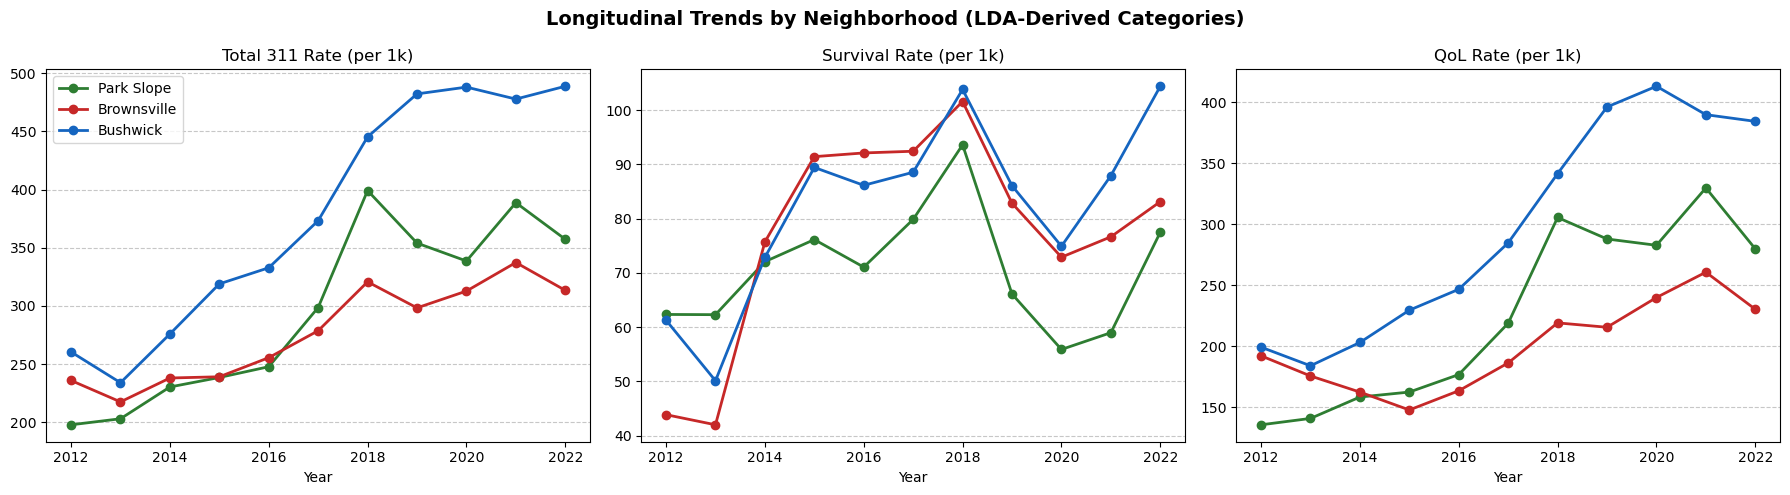

In [31]:
# setup for plots
ZIPS = ['11215', '11212', '11237']
ZIP_LABELS = {'11215': 'Park Slope', '11212': 'Brownsville', '11237': 'Bushwick'}
PALETTE = {'11215': '#2E7D32', '11212': '#C62828', '11237': '#1565C0'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Longitudinal Trends by Neighborhood (LDA-Derived Categories)', fontsize=14, fontweight='bold')

metrics = [
    ('total_rate', 'Total 311 Rate (per 1k)'),
    ('survival_rate', 'Survival Rate (per 1k)'),
    ('qol_rate', 'QoL Rate (per 1k)')
]

for i, (col, label) in enumerate(metrics):
    ax = axes[i]
    for z in ZIPS:
        sub = analysis_df[analysis_df['ZIP'].astype(str) == z].sort_values('YEAR')
        ax.plot(sub['YEAR'], sub[col], marker='o', color=PALETTE[z], label=ZIP_LABELS[z], linewidth=2)
    
    ax.set_title(label)
    ax.set_xlabel('Year')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

axes[0].legend()
plt.tight_layout()
plt.show()

### 3.3) the under reporting gap (survival v poverty)

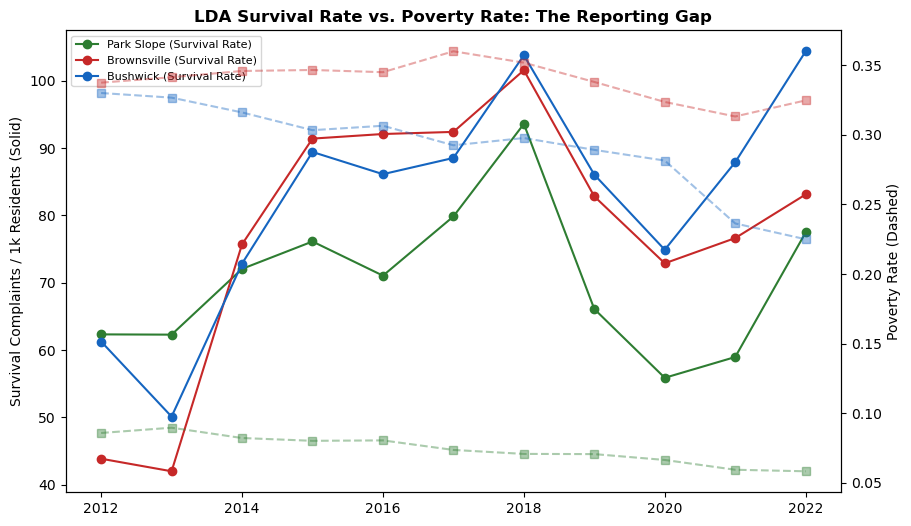

In [32]:
# replicating the dual-axis "Reporting Gap" plot
fig, ax = plt.subplots(figsize=(10, 6))

for z in ZIPS:
    sub = analysis_df[analysis_df['ZIP'].astype(str) == z].sort_values('YEAR')
    # Solid line: Survival complaints
    ax.plot(sub['YEAR'], sub['survival_rate'], marker='o', color=PALETTE[z], label=f'{ZIP_LABELS[z]} (Survival Rate)')

# create a second y-axis for Poverty Rate
ax2 = ax.twinx()
for z in ZIPS:
    sub = analysis_df[analysis_df['ZIP'].astype(str) == z].sort_values('YEAR')
    
    # dashed line = poverty rate
    ax2.plot(sub['YEAR'], sub['poverty_rate'], marker='s', linestyle='--', color=PALETTE[z], alpha=0.4, label=f'{ZIP_LABELS[z]} (Poverty %)')

ax.set_ylabel('Survival Complaints / 1k Residents (Solid)')
ax2.set_ylabel('Poverty Rate (Dashed)')
ax.set_title('LDA Survival Rate vs. Poverty Rate: The Reporting Gap', fontweight='bold')
ax.legend(loc='upper left', fontsize=8)
plt.show()

### 3.4) bushwick case study (spike in QoL)

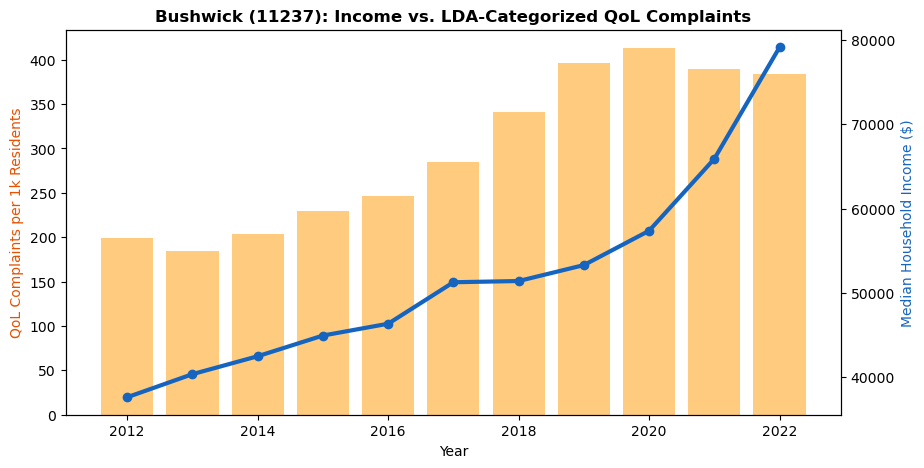

In [33]:
# focus on Bushwick (11237)
bushwick = analysis_df[analysis_df['ZIP'].astype(str) == '11237'].sort_values('YEAR')

fig, ax1 = plt.subplots(figsize=(10, 5))

# bar chart for QoL rate
ax1.bar(bushwick['YEAR'], bushwick['qol_rate'], color='#FF9800', alpha=0.5, label='LDA QoL Rate')
ax1.set_xlabel('Year')
ax1.set_ylabel('QoL Complaints per 1k Residents', color='#E65100')

# line chart for income
ax2 = ax1.twinx()
ax2.plot(bushwick['YEAR'], bushwick['median_hh_inc'], color='#1565C0', marker='o', linewidth=3, label='Median HH Income')
ax2.set_ylabel('Median Household Income ($)', color='#1565C0')

plt.title('Bushwick (11237): Income vs. LDA-Categorized QoL Complaints', fontweight='bold')
plt.show()

### 3.5) advanced panel regression

In [34]:
# prep categorical variables for fixed effects
reg_df = analysis_df.copy()
reg_df['ZIP_fe'] = reg_df['ZIP'].astype('category')
reg_df['YEAR_fe'] = reg_df['YEAR'].astype('category')

# model: Does income predict the QoL Rate, controlling for ZIP and Year specific traits?
fe_model = smf.ols('qol_rate ~ inc_10k + pct_white + poverty_rate + C(ZIP_fe) + C(YEAR_fe)', data=reg_df).fit()

print("Fixed Effects Regression: Predictors of LDA QoL Rate")
print(fe_model.summary().tables[1])

Fixed Effects Regression: Predictors of LDA QoL Rate
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            140.5301    200.927      0.699      0.494    -283.389     564.449
C(ZIP_fe)[T.11215]  -695.9010    149.361     -4.659      0.000   -1011.025    -380.777
C(ZIP_fe)[T.11237]   -77.1513     41.626     -1.853      0.081    -164.975      10.673
C(YEAR_fe)[T.2013]   -15.1030     17.948     -0.841      0.412     -52.971      22.765
C(YEAR_fe)[T.2014]   -11.9653     17.896     -0.669      0.513     -49.722      25.792
C(YEAR_fe)[T.2015]   -17.2257     18.210     -0.946      0.357     -55.645      21.193
C(YEAR_fe)[T.2016]   -10.2802     18.839     -0.546      0.592     -50.027      29.467
C(YEAR_fe)[T.2017]    11.1681     20.000      0.558      0.584     -31.028      53.364
C(YEAR_fe)[T.2018]    62.0507     20.744      2.991      0.008      18.286   

### 3.6) print values for comparison

In [35]:
# stats for LDA-derived rates
stats_summary = analysis_df[['total_rate', 'survival_rate', 'qol_rate', 'qol_survival_ratio']].describe().round(2)

# pull regression coefficients (matching the analysis.ipynb table)
def get_coef(target):
    try:
        formula = f"{target} ~ inc_10k + pct_white + poverty_rate"
        model = smf.ols(formula, data=analysis_df).fit()
        return model.params['inc_10k'], model.pvalues['inc_10k'], model.rsquared
    except:
        return np.nan, np.nan, np.nan

results = {}
for metric in ['total_rate', 'qol_rate', 'survival_rate', 'qol_survival_ratio']:
    coef, pval, r2 = get_coef(metric)
    results[metric] = {"Inc_10k_Coef": coef, "P-Value": pval, "R-Squared": r2}

reg_summary = pd.DataFrame(results).T.round(4)

print("\n" + "="*50)
print("LDA MODEL SUMMARY FOR COMPARISON")
print("="*50)
print()
print("* Descriptive Statistics (Rates per 1k) *")
print(stats_summary)
print()
print("* Impact of Income (inc_10k) on Categories *")
print(reg_summary)
print()
print("* Neighborhood Average *")
print(analysis_df.groupby('ZIP')[['total_rate', 'survival_rate', 'qol_rate']].mean().round(2))
print("="*50)


LDA MODEL SUMMARY FOR COMPARISON

* Descriptive Statistics (Rates per 1k) *
       total_rate  survival_rate  qol_rate  qol_survival_ratio
count       33.00          33.00     33.00               33.00
mean       317.56          76.83    240.73                3.21
std         86.48          16.19     79.70                1.07
min        197.96          41.99    135.64                1.62
25%        239.20          66.09    176.79                2.26
50%        312.80          76.63    219.15                3.22
75%        357.26          88.53    284.71                3.68
max        488.67         104.38    413.05                5.59

* Impact of Income (inc_10k) on Categories *
                    Inc_10k_Coef  P-Value  R-Squared
total_rate               30.8160   0.0067     0.2408
qol_rate                 30.0136   0.0037     0.2738
survival_rate             0.8023   0.7196     0.0464
qol_survival_ratio        0.4092   0.0025     0.3177

* Neighborhood Average *
       total_rate  

## 4) comparing against manual sorting results

### 4.1) general notes on differences

Recap of how the LDA model approach differs from the manual sorting...

Granularity: the manual code grouped "Rodents" and "Snow" together. however, the LDA model found that "Rodents" (Topic 8) is actually linked to "Sewer" and "Traffic" issues, while "Unsanitary conditions" (Topic 2) is a separate type of complaint involving vacant lots

Missed maintenance category: my manual keywords missed the heavy correlation between "Paint" and "Plaster" (Topic 9). The model found this distinct "Housing Quality" cluster that accounts for a huge volume of NYC complaints.

Efficiency: this allowed us to replace a long, complex if/elif block of keywords with a single mathematical model that can handle new types of complaints as they appear in the future (and doesn't require seven hours of coding and combing. why didn't I just do this in the first place)

### 4.2) robust digital fingerprint

MOST IMPORTANT FINDING: our primary conclusion re QoL/survival complaint ratios holds true across both methods!
> - manual: inc_10k coefficient for QoL/survival ratio was 0.435 (p \< 0.05)
> - LDA: inc_10k coefficient for QoL/survival ratio was 0.409 (p = 0.0025)

as income increases, the volume of quality of life complaints rises significantly faster than the volume of survival complaints
(the similarity in coefficients is a good sign that we actually manually sorted pretty similarly to what the LDA did)

### 4.3) LDA categorization of QoL

The LDA categorized Quality of Life complaints more broadly than we did, including thematic clusters such as obstacles, parks_safety, and street_maintenance, while the manual sorting was focused on specific keywords (like noise or trash).

This difference led to a noticeable increase in the total reported QoL complaint rates between manual and LDA data:
> - manual: approx 168 per 1,000 residents
> - LDA: approx 240 per 1,000 residents

Because of this, the LDA model reports higher QoL/survival rates across the board than the manually sorted approach (3.21 vs 2.40)

### 4.4) survival needs (where the methods diverge)

> - manual survival complaint rate = approx 90 per 1,000 residents
> - LDA survival complaint rate = approx 77 per 1,000 residents

This tracks with what we found in 4.3, and actually speaks to a benefit of manual sorting. The LDA model grouped hpd, interior, and subterranean complaints into survival, but our keyword searching ensured that issues with heat or water all made it into the survival category (and the LDA model may have lost some of those).

### 4.5) income statistical significance

The relationship between avg income and call volume is much stronger with the LDA data. We think this is because the LDA model is better at picking up on subtle nuisance complaints that wealthier residents may be more likely to report. This also suggests that wealthier communities are in fact more frequent 311 callers than lower income communities, an interesting relationship that wasn't as apparent in the results from the manually sorted data.

coefficients for total rate of income to volume:
> - manual: 11.61 (p = 0.239)
> - LDA: 30.81 (p = 0.0067s)

### 4.6) summary of comparison findings

| Metric | Manual method (keyword)| LDA method (topic model) | Interpretation |
| :--- | :--- | :--- | :--- |
| Total Rate (mean) | 310.67 | 317.56 | High Agreement: both capture total volume equally |
| QoL Rate (Mean) | 168.42 | 240.73 | LDA is broader: Captures more subtle nuisance types |
| Survival Rate (Mean) | 89.76 | 76.83 | Manual is stricter: Focuses more on core housing |
| Income Impact (Ratio) | 0.435 (p < .05) | 0.409 (p < .01) | Finding Validated: Income predicts QoL focus |

